<a href="https://colab.research.google.com/github/seadawolie/ores5160-2025/blob/main/week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


In [ ]:
import pandas as pd

df = pd.read_csv('est2018-pop-res (1) (1).psv', sep='|')

# Display the shape (rows × columns)
print(f"DataFrame shape: {df.shape}")

# Print the list of column names
print("Column names:")
for col in df.columns:
    print(f"- {col}")

DataFrame shape: (53, 8)
Column names:
- SUMLEV
- REGION
- DIVISION
- STATE
- NAME
- POPESTIMATE2018
- POPEST18PLUS2018
- PCNT_POPEST18PLUS


In [ ]:
from google.colab import files
files.upload()

Saving est2018-pop-res (1).psv to est2018-pop-res (1) (1).psv


{'est2018-pop-res (1) (1).psv': b'SUMLEV|REGION|DIVISION|STATE|NAME|POPESTIMATE2018|POPEST18PLUS2018|PCNT_POPEST18PLUS\r\n010|0|0|00|United States|327167434|253768092|77.6\r\n040|3|6|01|Alabama|4887871|3798031|77.7\r\n040|4|9|02|Alaska|737438|553622|75.1\r\n040|4|8|04|Arizona|7171646|5528989|77.1\r\n040|3|7|05|Arkansas|3013825|2310645|76.7\r\n040|4|9|06|California|39557045|30567090|77.3\r\n040|4|8|08|Colorado|5695564|4430329|77.8\r\n040|1|1|09|Connecticut|3572665|2837472|79.4\r\n040|3|5|10|Delaware|967171|763555|78.9\r\n040|3|5|11|District of Columbia|702455|574961|81.9\r\n040|3|5|12|Florida|21299325|17070244|80.1\r\n040|3|5|13|Georgia|10519475|8013724|76.2\r\n040|4|9|15|Hawaii|1420491|1117077|78.6\r\n040|4|8|16|Idaho|1754208|1307236|74.5\r\n040|2|3|17|Illinois|12741080|9883814|77.6\r\n040|2|3|18|Indiana|6691878|5123748|76.6\r\n040|2|4|19|Iowa|3156145|2425378|76.8\r\n040|2|4|20|Kansas|2911505|2205544|75.8\r\n040|3|6|21|Kentucky|4468402|3459573|77.4\r\n040|3|7|22|Louisiana|4659978|35640

Average population across all states: 6,353,127

Region with the highest total population (Region ID): 3
Total population in this region: 124,753,948



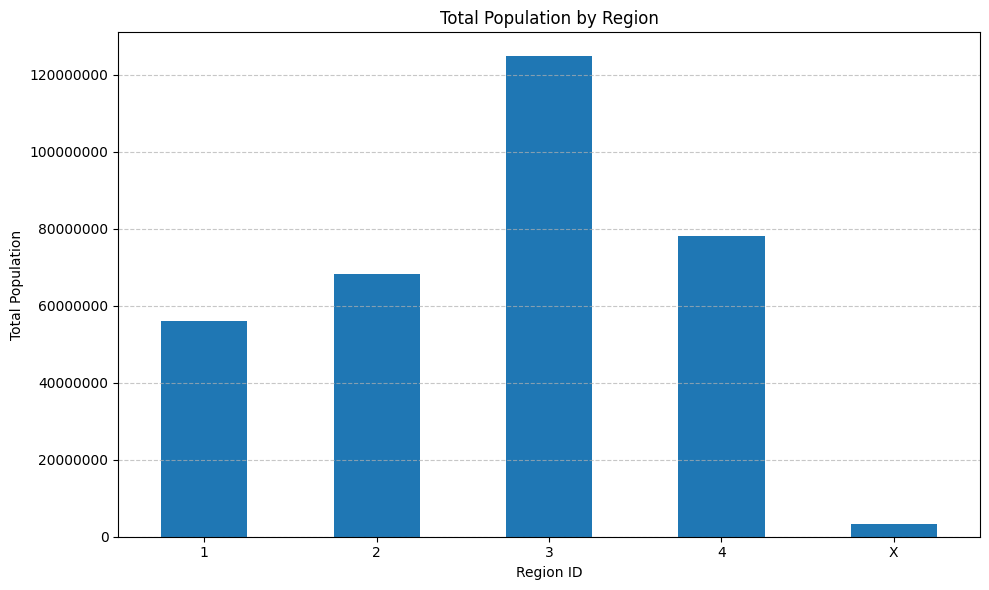

In [ ]:
# 1. Compute the average population across all states
average_population = state_df['POPESTIMATE2018'].mean()
print(f"Average population across all states: {average_population:,.0f}\n")

# 2. Find which region has the highest total population
# Group by 'REGION' and sum the 'POPESTIMATE2018' to get total population per region
population_by_region = state_df.groupby('REGION')['POPESTIMATE2018'].sum()

# Find the region with the highest total population
highest_population_region = population_by_region.idxmax()
max_population_value = population_by_region.max()

print(f"Region with the highest total population (Region ID): {highest_population_region}")
print(f"Total population in this region: {max_population_value:,.0f}\n")

# 3. Plot a bar chart showing the population by region (use matplotlib)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
population_by_region.plot(kind='bar')
plt.title('Total Population by Region')
plt.xlabel('Region ID')
plt.ylabel('Total Population')
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Which column represents total population?
print("The column representing total population is: POPESTIMATE2018\n")

# Display the top 5 most populous states
print("Top 5 most populous states:")
# Filter out 'United States' which is the aggregate total, and then sort.
# Assuming 'NAME' column contains state names.
# We are looking for rows where SUMLEV is 040 (state level summary)
# or filtering by 'NAME' not being 'United States'. Let's go with the latter for simplicity
# and then ensure we only consider states (SUMLEV == 040 if it exists).

# Let's check SUMLEV values to confirm state level.
# df['SUMLEV'].value_counts()

# Assuming rows with SUMLEV == 040 are states, and 010 is United States total.
state_df = df[df['SUMLEV'] == 40.0]

top_5_states = state_df.sort_values(by='POPESTIMATE2018', ascending=False).head(5)
print(top_5_states[['NAME', 'POPESTIMATE2018']].to_string(index=False))

The column representing total population is: POPESTIMATE2018

Top 5 most populous states:
        NAME  POPESTIMATE2018
  California         39557045
       Texas         28701845
     Florida         21299325
    New York         19542209
Pennsylvania         12807060


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

In [ ]:
import json

# 1. Load patient.json into a Python dictionary
with open('patient.json', 'r') as f:
    patient_data = json.load(f)

print("--- Patient Information ---\n")

# 2. Extract and print:
# Patient’s full official name
name_parts = patient_data['name'][0]['given'] + patient_data['name'][0]['family'].split()
full_name = ' '.join(name_parts)
print(f"Full Official Name: {full_name}")

# Gender and birth date
gender = patient_data['gender']
birth_date = patient_data['birthDate']
print(f"Gender: {gender}")
print(f"Birth Date: {birth_date}")

# Current address (city, state, postal code)
address = patient_data['address'][0]
city = address.get('city', 'N/A')
state = address.get('state', 'N/A')
postal_code = address.get('postalCode', 'N/A')
print(f"Current Address: {city}, {state}, {postal_code}")

# 3. Count how many phone numbers the patient has, and list their types
telecom_numbers = patient_data.get('telecom', [])
phone_numbers = [item for item in telecom_numbers if item.get('system') == 'phone']

num_phone_numbers = len(phone_numbers)
phone_types = [item.get('use', 'N/A') for item in phone_numbers]

print(f"\nNumber of phone numbers: {num_phone_numbers}")
print(f"Phone number types: {', '.join(phone_types)}")

--- Patient Information ---

Full Official Name: Peter James Chalmers
Gender: male
Birth Date: 1974-12-25
Current Address: PleasantVille, Vic, 3999

Number of phone numbers: 3
Phone number types: work, mobile, old


Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

### Population Distribution Across States

Let's visualize the distribution of `POPESTIMATE2018` for all states to understand how state populations are spread.

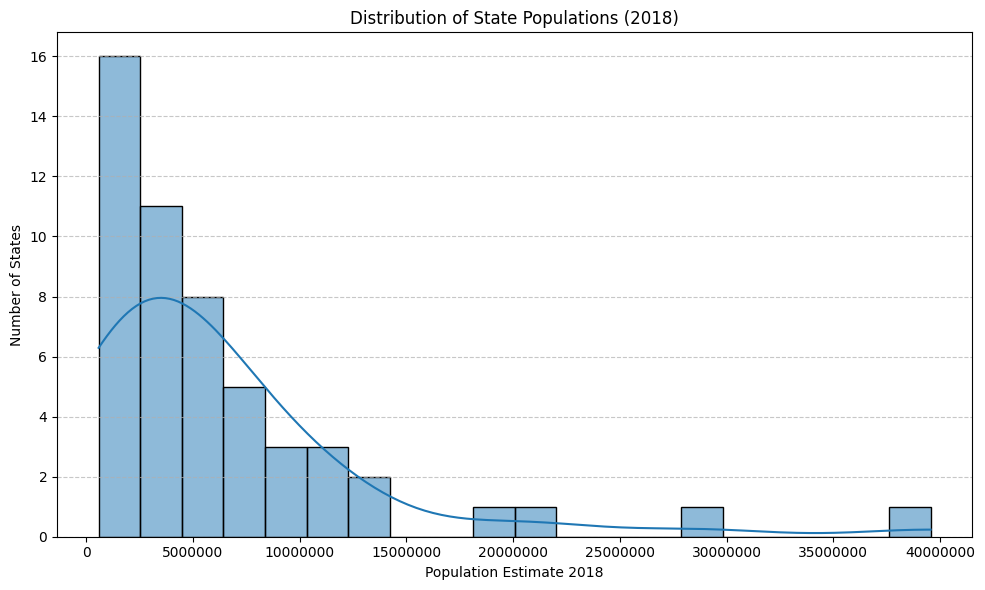

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are using state-level data
# state_df was already created as df[df['SUMLEV'] == 40.0]

plt.figure(figsize=(10, 6))
sns.histplot(state_df['POPESTIMATE2018'], bins=20, kde=True)
plt.title('Distribution of State Populations (2018)')
plt.xlabel('Population Estimate 2018')
plt.ylabel('Number of States')
plt.ticklabel_format(style='plain', axis='x') # Disable scientific notation on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Population by Division

Next, let's group the states by `DIVISION` and visualize the total population in each division. This helps in understanding regional population concentrations beyond just the broader `REGION` analysis we did earlier.

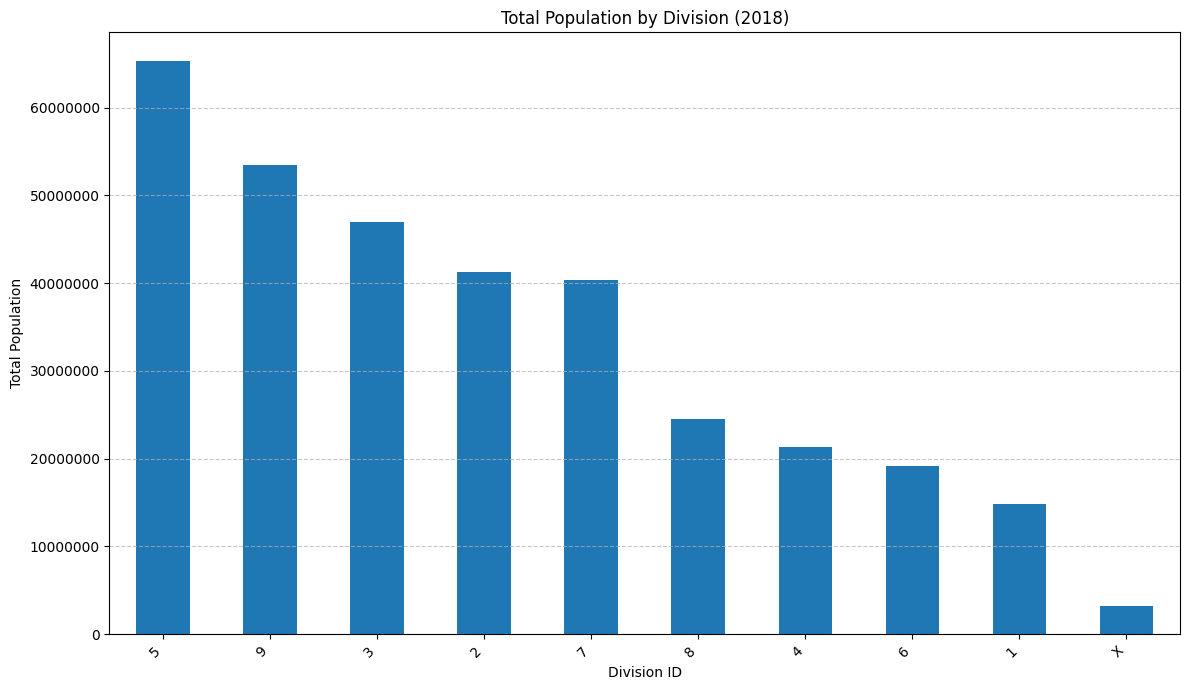

In [ ]:
population_by_division = state_df.groupby('DIVISION')['POPESTIMATE2018'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
population_by_division.plot(kind='bar')
plt.title('Total Population by Division (2018)')
plt.xlabel('Division ID')
plt.ylabel('Total Population')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Relationship between Total Population and Adult Population Percentage

Let's examine if there's any visible relationship between a state's total population (`POPESTIMATE2018`) and the percentage of its population that is 18 years or older (`PCNT_POPEST18PLUS`).

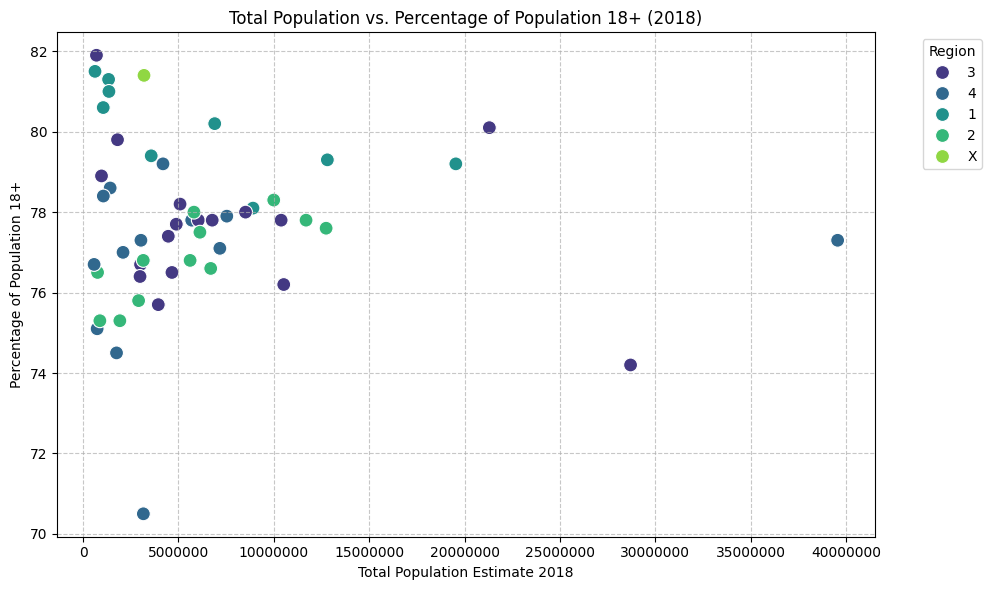

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=state_df, x='POPESTIMATE2018', y='PCNT_POPEST18PLUS', hue='REGION', palette='viridis', s=100)
plt.title('Total Population vs. Percentage of Population 18+ (2018)')
plt.xlabel('Total Population Estimate 2018')
plt.ylabel('Percentage of Population 18+')
plt.ticklabel_format(style='plain', axis='x')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()